So we need to train a model for a classic titanic survivor problem, given the ticket information and personal (age, sex, etc.) classify if the person survived on the titanic. If i correctly remember, the baseline model for this is random forest/decision tree, so we will start with it, and i also wanna try MLP for this problem and maybe SVM.

In [119]:
import pandas as pd
import numpy as np
import os
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, train_test_split


In [120]:
data_path = os.path.join(os.getcwd(), "data", "train.csv")
data = pd.read_csv(data_path)

In [131]:
def preprocess_data(data:pd.DataFrame) -> pd.DataFrame:
    clean = data
    clean = clean.drop(["PassengerId", "Name", "Ticket", "Cabin", "SibSp"], axis=1)
    le = LabelEncoder()
    clean["Sex"] = le.fit_transform(data["Sex"])
    clean["Embarked"] = le.fit_transform(data["Embarked"])
    clean["Age"] = clean["Age"].fillna(data["Age"].mean())
    return clean

In [132]:
preprocessed_data = preprocess_data(data)
X_train, X_test, y_train, y_test = train_test_split(preprocessed_data.iloc[:, 1:], preprocessed_data.iloc[:, 0],
                                                    test_size=0.25,
                                                    random_state=42)
X_train.head()


,Pclass,Sex,Age,Parch,Fare,Embarked
298,1,1,29.699118,0,30.5000,2
884,3,1,25.000000,0,7.0500,2
247,2,0,24.000000,2,14.5000,2
478,3,1,22.000000,0,7.5208,2
305,1,1,0.920000,2,151.5500,2


In [134]:
depth_range = [None]
depth_range.extend(range(1,6))
param_map = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": depth_range,
}
decission_tree = GridSearchCV(DecisionTreeClassifier(), param_map)
decission_tree.fit(X_train, y_train)
decission_tree.score(X_test, y_test)


0.8026905829596412

In [135]:
decission_tree.best_params_

{'criterion': 'gini', 'max_depth': 3}

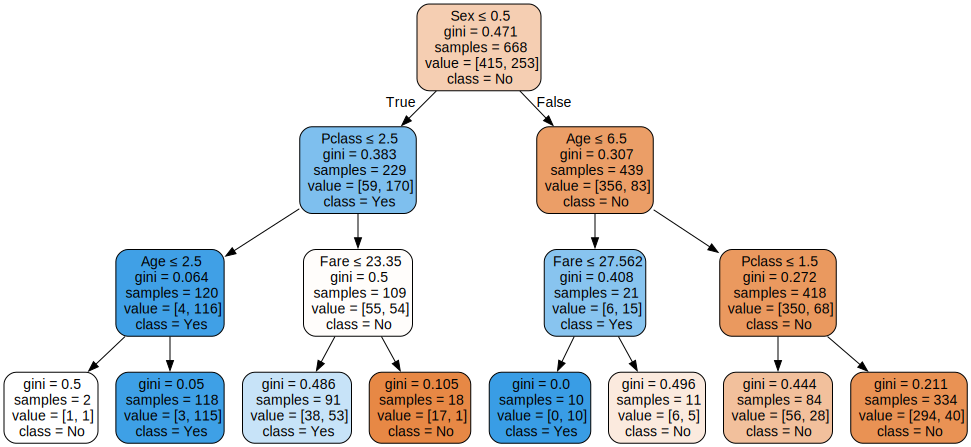

In [ ]:
features = list(X_train)[:7]
dot_data = export_graphviz(decission_tree.best_estimator_,
                           out_file=None,
                           feature_names=list(features),
                           class_names=["No", "Yes"], 
                            filled=True, 
                            rounded=True,  
                            special_characters=True)
graph = graphviz.Source(dot_data)
display(graph)

In [145]:
y_train[y_train == 1].count

<bound method Series.count of 298    1
247    1
305    1
316    1
2      1
      ..
458    1
330    1
700    1
106    1
435    1
Name: Survived, Length: 253, dtype: int64>

only 300 survivors, and the tree shows that the biggest factor of surviving is gender, from 300, model classified 200 in female section, and only 10 in male (and all are kids <=6.5 y.o). Looking at gini index, model are most sure that you are a survivor if you either mid/upper class female, or a male kid

In [147]:
param_map = {
    "n_estimators" : list(range(80, 220, 20)),
    "criterion" : ["gini", "entropy", "log_loss"],
    "max_depth" : list(range(2, 6))
}

random_forest = GridSearchCV(RandomForestClassifier(), param_map)
random_forest.fit(X_train, y_train)
random_forest.score(X_test, y_test)

0.8161434977578476

In [148]:
random_forest.best_params_

{'criterion': 'log_loss', 'max_depth': 5, 'n_estimators': 160}

I believe you cant achieve very high accuracy here, because after all death is not very predictable, sometimes its just luck, correct time or place.

In [149]:
param_map = {
    "gamma" : [0, 1],
    "alpha" : [0, 1],
    "lambda" : [0, 1],
    "max_depth" : list(range(2, 8))
}

xgb = GridSearchCV(XGBClassifier(), param_map)
xgb.fit(X_train, y_train)
xgb.score(X_test, y_test)

0.8116591928251121

In [150]:
xgb.best_params_

{'alpha': 0, 'gamma': 1, 'lambda': 0, 'max_depth': 3}

Worse than random forest by 0.05%, i would say that is no difference on 700 samples, and still 80% limit, i guess it's just how much we can get from that information.

In [159]:
clf = SVC(C=5).fit(X_train, y_train)
clf.score(X_test, y_test)

0.672645739910314

Not even close to the random forest, if we just ask if passanger is female or not, and on yes we say it is a survivor we would get better results

In [212]:
clf = MLPClassifier(hidden_layer_sizes=(40)).fit(X_train, y_train)
clf.score(X_test, y_test)

c:\Users\vital\anaconda3\envs\DScamp\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:702: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7757847533632287

range of 74-79%, not bad, but still decision tree wins.

In conclusion. The best model was random forest with 81.5% accuracy, maybe i should have used different metrics, like f1, but for learning purposes thats enough. I think it was an easy task (81.5% is good in terms of given information and in terms what we are trying to predict) for random forest because the pattern is really easy, it can ask 2 question about age and gender and give a 77% accuracy, and data is really good for asking questions, small ammount of features and most of the features have a small ammount of possible answers (2-4), so asking questions is easier, than trying to find a pattern by approximating a function (however the MLP shows us that if the function is big enough it still can do good, and also proves that pattern is easy, it only need 40 neurons and 7*40+80 = 360 weights to give a good enough approximation (and with 20 neurons it still 70-75%)).